In [14]:
# -*- coding: utf-8 -*-
"""HODLR.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/14KvYWxP0tBlyzeegHUdHDvBnIZciWb6V
"""

import numpy as np
from math import sqrt
from numpy.linalg import norm
from time import perf_counter
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---

# Reproducibility
np.random.seed(42)

## Global constants and toggles
##DEFAULT_USE_LOWRANK = True        # Set True for RandSVD/HODLR experiments
##DEFAULT_RANK_K = 20               # Target rank for low-rank approximations
##DEFAULT_POWER_ITERS = 1           # Power iterations for randomized SVD

CHEB_P = 8         #Chebyshev interpolation rank
MIN_BLOCK = 16     #Leaf size for HODLR recursion

# Choose Low-Rank Method (Change this in the experiment section)
# Options: 'ACA', 'RAND_SVD', 'HODLR'
#LOWRANK_METHOD = 'HODLR'


# --- 2. DATA GENERATION (Mixture of Gaussians) ---

rng = np.random.default_rng(42)
N = 100  # Reduced for quick testing

# Mixture on R_+ (positive axis): Two Gaussian components
x = np.abs(np.concatenate([
    rng.normal(loc=2.0, scale=0.4, size=N//2),
    rng.normal(loc=5.0, scale=0.7, size=N - N//2)
])).astype(float)
x.sort()

# Midpoints z_k between consecutive ordered samples; M = N-1
z = 0.5 * (x[:-1] + x[1:])
M = z.shape[0]

# Empirical CDF at midpoints: T_k = k/N, k = 1..N-1
T = np.arange(1, N) / N

# --- 3. GAUSSIAN KERNEL FUNCTIONS & MATRIX BUILDERS ---

SQRT2 = sqrt(2.0)
INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

In [15]:
def generate_mixture_gaussian_data(N, seed=42):
    """Generate mixture of Gaussians data (using existing logic)."""
    rng = np.random.default_rng(seed)
    x = np.abs(np.concatenate([
        rng.normal(loc=2.0, scale=0.4, size=N//2),
        rng.normal(loc=5.0, scale=0.7, size=N - N//2)
    ])).astype(float)
    x.sort()
    return x

def generate_exponential_data(N, seed=42):
    """Generate exponential distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.exponential(scale=2.0, size=N)
    x.sort()
    return x

def generate_uniform_data(N, seed=42):
    """Generate uniform distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(low=0.0, high=10.0, size=N)
    x.sort()
    return x

def generate_lognormal_data(N, seed=42):
    """Generate log-normal distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.lognormal(mean=1.0, sigma=0.5, size=N)
    x.sort()
    return x

def generate_beta_data(N, seed=42):
    """Generate beta distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.beta(a=2.0, b=5.0, size=N) * 10.0  # Scale to [0, 10]
    x.sort()
    return x

In [16]:
#normal pdf
def kappa(u):
    """Standard normal pdf φ(u). Vectorized."""
    return INV_SQRT_2PI * np.exp(-0.5 * u * u)

#normal cdf
def K(u):
    """Standard normal cdf Φ(u) via erf. Vectorized."""
    return 0.5 * (1.0 + erf(u / SQRT2))

In [17]:
def cheb_points(p):
    return np.cos((2*np.arange(p)+1)*np.pi/(2*p)) #return p chebyshev nodes in [-1,1]

def scale11(x, a, b):
    return (2*x - (a+b)) / (b-a)  #maps any interval [a,b] to [-1,1]

def chebyshev_polynomials(x, p):
    x = np.asarray(x)
    T = np.zeros((len(x), p))
    T[:,0] = 1.0
    if p > 1: T[:,1] = x
    for n in range(2, p):
        T[:,n] = 2*x*T[:,n-1] - T[:,n-2]
    return T

#computes U and V for one off diagonal block using baycentric lagrange
def cheb_UV(z_blk, x_blk, p):
    az, bz = z_blk.min(), z_blk.max()
    ax, bx = x_blk.min(), x_blk.max()
    if bz == az: bz += 1e-10
    if bx == ax: bx += 1e-10
    t = cheb_points(p)
    Tt  = chebyshev_polynomials(t, p)
    W   = (2/p) * np.where(np.arange(p)==0, 0.5, 1.0)
    WTt = W[:,None] * Tt.T
    Tz  = chebyshev_polynomials(scale11(zb,az,bz), p)
    Tx  = chebyshev_polynomials(scale11(xb,ax,bx), p)
    U   = Tz @ WTt
    V   = Tx @ WTt
    return U, V

#Evaluates Gaussian CDF kernel only at pxp chebyshev node pairs, returns S only at pxp
def cheb_S_K(z_blk, x_blk, h_blk, p):
    az, bz = z_blk.min(), z_blk.max()
    ax, bx = x_blk.min(), x_blk.max()
    if bz == az: bz += 1e-10
    if bx == ax: bx += 1e-10
    t = cheb_points(p)
    zc = 0.5*(bz-az)*t + 0.5*(bz+az)
    xc = 0.5*(bx-ax)*t + 0.5*(bx+ax)
    return K((zc[:,None] - xc[None,:]) / h_blk.mean())

def cheb_S_D(z_blk, x_blk, h_blk, p):
    az, bz = z_blk.min(), z_blk.max()
    ax, bx = x_blk.min(), x_blk.max()
    if bz == az: bz += 1e-10
    if bx == ax: bx += 1e-10
    t = cheb_points(p)
    zc = 0.5*(bz-az)*t + 0.5*(bz+az)
    xc = 0.5*(bx-ax)*t + 0.5*(bx+ax)
    h_mean = h_blk.mean()
    diff = zc[:,None] - xc[None,:]
    return -kappa(diff/h_mean) * diff / (h_mean**2)




# CHEBYSHEV BASED HODLR IMPLEMENTATION (NO DENSE MATRIX)

#Always apply Chebyshev to off-diagonal blocks
def is_admissible(z_blk, x_blk):
    #For Gaussian CDF kernel, off-diagonal blocks are low-rank due to smoothness of the kernel, not spatial separation.
    #Singular values decay to 1e-16 at p=8 even for adjacent blocks. So always apply Chebyshev to off-diagonal blocks.
    return True

def hodlr_build_UV(z, x, p=8, min_block=16):
    #Build UV structure once. No kernel evaluations here.
    def build(zi, xi):
        z_blk = z[zi]; x_blk = x[xi]
        if len(zi) <= min_block or len(xi) <= min_block:
            return {'type': 'dense', 'zi': zi, 'xi': xi}

        zm = len(zi)//2; xm = len(xi)//2
        zi1, zi2 = zi[:zm], zi[zm:]
        xi1, xi2 = xi[:xm], xi[xm:]

        def make_off(zii, xii):
            zb = z[zii]; xb = x[xii]
            az, bz = zb.min(), zb.max()
            ax, bx = xb.min(), xb.max()
            if bz == az: bz += 1e-10
            if bx == ax: bx += 1e-10
            t = cheb_points(p)
            Tt  = chebyshev_polynomials(t, p)
            W   = (2/p) * np.where(np.arange(p)==0, 0.5, 1.0)
            WTt = W[:,None] * Tt.T
            Tz  = chebyshev_polynomials(scale11(zb,az,bz), p)
            Tx  = chebyshev_polynomials(scale11(xb,ax,bx), p)
            U   = Tz @ WTt
            V   = Tx @ WTt
            zc = 0.5*(bz-az)*t + 0.5*(bz+az)  # physical Cheb nodes
            xc = 0.5*(bx-ax)*t + 0.5*(bx+ax)
            return {'type': 'lowrank', 'U': U, 'V': V,
                    'zc': zc, 'xc': xc, 'xi': xii}

        return {'type': 'node',
                'H11': build(zi1, xi1), 'H22': build(zi2, xi2),
                'off12': make_off(zi1, xi2), 'off21': make_off(zi2, xi1),
                'zi': zi, 'xi': xi, 'zm': zm}

    return build(np.arange(len(z)), np.arange(len(x)))


def hodlr_fill_S_K(node, z, x, h):
    #Fill S for KDE forward pass, called each iteration. This calls only pxp S matrices, as U and V are already fixed
    if node['type'] == 'dense':
        zi, xi = node['zi'], node['xi']
        node['K'] = K((z[zi][:,None] - x[xi][None,:]) / h[xi][None,:])
        return
    hodlr_fill_S_K(node['H11'], z, x, h)
    hodlr_fill_S_K(node['H22'], z, x, h)
    for off in [node['off12'], node['off21']]:
        h_mean = h[off['xi']].mean()
        off['S'] = K((off['zc'][:,None] - off['xc'][None,:]) / h_mean)


def hodlr_fill_S_D(node, z, x, h):
    #Fill S for gradient pass, called each iteration. This calls only pxp S matrices, as U and V are already fixed
    if node['type'] == 'dense':
        zi, xi = node['zi'], node['xi']
        diff = z[zi][:,None] - x[xi][None,:]
        hloc = h[xi][None,:]
        node['K'] = -kappa(diff/hloc) * diff / (hloc**2)
        return
    hodlr_fill_S_D(node['H11'], z, x, h)
    hodlr_fill_S_D(node['H22'], z, x, h)
    for off in [node['off12'], node['off21']]:
        h_mean = h[off['xi']].mean()
        diff = off['zc'][:,None] - off['xc'][None,:]
        off['S'] = -kappa(diff/h_mean) * diff / (h_mean**2)

# Matrix-vector product
#Computes kxv without forming K, each off diagonal does U@(S@(V^t @ v)), three small matrix vector products instead of one large one.
def hodlr_matvec(node, v):

    if node['type'] == 'dense':
        return node['K'] @ v[node['xi']]

    zm = node['zm']
    out = np.zeros(len(node['zi']))

    # Diagonal
    out[:zm]  += hodlr_matvec(node['H11'], v)
    out[zm:]  += hodlr_matvec(node['H22'], v)

    # Off-diagonal 12
    off12 = node['off12']
    if off12['type'] == 'lowrank':
        out[:zm] += off12['U'] @ (off12['S'] @ (off12['V'].T @ v[off12['xi']]))
    else:
        out[:zm] += off12['K'] @ v[off12['xi']]

    # Off-diagonal 21
    off21 = node['off21']
    if off21['type'] == 'lowrank':
        out[zm:] += off21['U'] @ (off21['S'] @ (off21['V'].T @ v[off21['xi']]))
    else:
        out[zm:] += off21['K'] @ v[off21['xi']]

    return out



# Transpose matrix-vector product
#computes K^t @ r
def hodlr_rmatvec(node, r):

    N_total = node['xi'][-1] + 1

    def recurse(nd, r_sub):
        if nd['type'] == 'dense':
            g = np.zeros(N_total)
            g[nd['xi']] += nd['K'].T @ r_sub
            return g

        zm = nd['zm']
        r1, r2 = r_sub[:zm], r_sub[zm:]
        g = np.zeros(N_total)

        g += recurse(nd['H11'], r1)
        g += recurse(nd['H22'], r2)

        off12 = nd['off12']
        if off12['type'] == 'lowrank':
            g[off12['xi']] += off12['V'] @ (off12['S'].T @ (off12['U'].T @ r1))
        else:
            g[off12['xi']] += off12['K'].T @ r1

        off21 = nd['off21']
        if off21['type'] == 'lowrank':
            g[off21['xi']] += off21['V'] @ (off21['S'].T @ (off21['U'].T @ r2))
        else:
            g[off21['xi']] += off21['K'].T @ r2

        return g

    return recurse(node, r)

In [18]:
def solve_kde_enhanced(x, z, T, *,
                       method='DENSE',
                       p=8,
                       min_block=16,
                       eta=0.5,
                       max_iters=400,
                       tol=1e-8,
                       verbose=False):

    N = len(x)
    M = len(z)

    time_build = 0.0
    time_ops   = 0.0

    J_hist = []
    t_hist = []
    grad_norm_hist = []

    t0_total = perf_counter()

    # Build UV structure once for CHEB_HODLR
    if method == 'CHEB_HODLR':
        t0 = perf_counter()
        tree = hodlr_build_UV(z, x, p=p, min_block=min_block)
        time_build += perf_counter() - t0


    # Forward KDE evaluation
    def _F_hat(h):
        nonlocal time_build, time_ops

        if method == 'DENSE':
            t0 = perf_counter()
            U_arg = (z[:, None] - x[None, :]) / h[None, :]
            y = K(U_arg) @ np.ones(N) / N
            time_ops += perf_counter() - t0
            return y

        elif method == 'CHEB_HODLR':
            t0 = perf_counter()
            hodlr_fill_S_K(tree, z, x, h)   # only recomputes p×p S matrices
            time_build += perf_counter() - t0
            t1 = perf_counter()
            y = hodlr_matvec(tree, np.ones(N)) / N
            time_ops += perf_counter() - t1
            return y

    # Gradient — returns (gradient, J_curr) to avoid extra fill
    def _grad_J(h):
        nonlocal time_build, time_ops

        r = _F_hat(h) - T
        J_curr = float(r @ r)

        if method == 'DENSE':
            diff = z[:, None] - x[None, :]
            U_arg = diff / h[None, :]
            D = -kappa(U_arg) * diff / (h[None, :]**2)
            g = (2.0 / N) * (D.T @ r)

        elif method == 'CHEB_HODLR':
            t0 = perf_counter()
            hodlr_fill_S_D(tree, z, x, h)   # reuse same tree structure
            time_build += perf_counter() - t0
            t1 = perf_counter()
            g = (2.0 / N) * hodlr_rmatvec(tree, r)
            time_ops += perf_counter() - t1

        return g, J_curr

    # _J only used for backtracking line search
    def _J(a):
        h_local = np.exp(a)
        r_local = _F_hat(h_local) - T
        return float(r_local @ r_local)

    # Initialization
    data_span = x.max() - x.min()
    h0 = max(0.2 * data_span / (N**0.2), 1e-3)
    h = np.full(N, h0)
    alpha = np.log(h)

    J0 = _J(alpha)
    J_hist.append(J0)
    t_hist.append(0.0)
    grad_norm_hist.append(0.0)

    if verbose:
        print(f"[{method}] Initial J = {J0:.6f}")

    # Gradient descent
    for k in range(max_iters):

        h = np.exp(alpha)

        grad_h, J_curr = _grad_J(h)
        grad_alpha = grad_h * h
        grad_norm  = norm(grad_alpha)

        alpha_new = alpha - eta * grad_alpha
        alpha_new = np.clip(alpha_new,
                            np.log(1e-3),
                            np.log(5.0 * data_span))

        J_new = _J(alpha_new)

        # Backtracking
        tries = 0
        while J_new > J_curr and tries < 10:
            eta *= 0.5
            alpha_new = alpha - eta * grad_alpha
            alpha_new = np.clip(alpha_new,
                                np.log(1e-3),
                                np.log(5.0 * data_span))
            J_new = _J(alpha_new)
            tries += 1

        alpha = alpha_new

        J_hist.append(J_new)
        t_hist.append(perf_counter() - t0_total)
        grad_norm_hist.append(grad_norm)

        if verbose and (k+1) % 20 == 0:
            print(f"iter {k+1:3d}: J={J_new:.6f}, ||grad||={grad_norm:.2e}")

        if grad_norm < tol:
            if verbose:
                print(f"Converged at iteration {k+1}")
            break

    h_opt = np.exp(alpha)

    metrics = {
        "method": method,
        "p": p,
        "min_block": min_block,
        "J_final": J_hist[-1],
        "J_initial": J_hist[0],
        "total_time": t_hist[-1],
        "time_build": time_build,
        "time_ops": time_ops,
        "iterations": len(J_hist) - 1,
        "final_grad_norm": grad_norm_hist[-1],
        "J_hist": J_hist,
        "t_hist": t_hist,
        "grad_norm_hist": grad_norm_hist,
        "h_stats": (
            float(h_opt.min()),
            float(np.median(h_opt)),
            float(h_opt.max())
        )
    }

    return h_opt, metrics

In [19]:
def true_mixture(u, SQRT2):
    """True mixture density from which data was drawn."""
    INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

    def component_pdf(u, loc, scale):
        u_scaled = (u - loc) / scale
        return (1/scale) * INV_SQRT_2PI * np.exp(-0.5 * u_scaled**2)

    f1 = component_pdf(u, loc=2.0, scale=0.4)
    f2 = component_pdf(u, loc=5.0, scale=0.7)

    result = 0.5 * f1 + 0.5 * f2
    result[u < 0] = 0
    return result

def kde_estimate(u, x, h):
    """Evaluate KDE at points u using sample points x and per-sample bandwidths h."""
    U = (u[:, None] - x[None, :]) / h[None, :]
    return np.mean(kappa(U) / h[None, :], axis=1)

In [20]:
def run_scaling_experiment(
    N_values=[500, 1000, 2000, 3000, 5000, 10000, 20000, 50000, 100000],
    ranks=[8, 12, 16],
    min_block=16
):
    """
    Chebyshev-HODLR vs Dense (FINAL CLEAN)

    ✔ Dense only up to 5000
    ✔ Cheb up to 100000
    ✔ 3 p values
    ✔ Only mixture Gaussian (as required)
    ✔ Matches plotting structure
    """

    results = {
        'dense': [],
        'hodlr': {}
    }

    print("="*80)
    print("CHEBYSHEV-HODLR vs DENSE KDE ANALYSIS")
    print("="*80)

    for N in N_values:
        print(f"\nN = {N}")

        # ===== DATA =====
        x = generate_mixture_gaussian_data(N)
        z = 0.5 * (x[:-1] + x[1:])
        T = np.arange(1, N) / N

        # ===== DENSE (ONLY up to 5000) =====
        if N <= 5000:
            print("  Running Dense baseline...")

            _, m_dense = solve_kde_enhanced(
                x, z, T,
                method='DENSE',
                max_iters=100,
                tol=1e-6,
                verbose=False
            )
            results['dense'].append(m_dense)
        else:
            results['dense'].append(None)   # keep alignment

        # ===== CHEBYSHEV-HODLR =====
        for p in ranks:
            key = f'p{p}'

            if key not in results['hodlr']:
                results['hodlr'][key] = []

            print(f"  Running CHEB_HODLR (p={p})...")

            # Faster settings for large N
            if N >= 10000:
                max_iters = 50
                tol = 1e-5
            else:
                max_iters = 100
                tol = 1e-6

            _, m_hodlr = solve_kde_enhanced(
                x, z, T,
                method='CHEB_HODLR',
                p=p,
                min_block=min_block,
                max_iters=max_iters,
                tol=tol,
                verbose=False
            )

            results['hodlr'][key].append(m_hodlr)

    return results, N_values

In [29]:
def build_Kmat(x, z, h):
    """
    Dense KDE matrix:
    K_{k,j} = Phi((z_k - x_j)/h_j)
    """
    U = (z[:, None] - x[None, :]) / h[None, :]
    return K(U)
import numpy as np
import matplotlib.pyplot as plt
import time

# ================= GLOBAL STYLE =================
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# =========================================================
# ✅ FIGURE 2 (COMBINED FOR 3 p VALUES)
# =========================================================
def fig2_cheb_matrix(N_values, p_values=[8,12,16]):

    build_all = {p: [] for p in p_values}
    matvec_all = {p: [] for p in p_values}
    error_all = {p: [] for p in p_values}

    for N in N_values:
        print(f"N={N}")
        x = generate_mixture_gaussian_data(N)
        z = 0.5*(x[:-1]+x[1:])
        h = np.full(N, 0.3)

        for p in p_values:
            print(f"  p={p}")

            # Build
            t0 = time.perf_counter()
            tree = hodlr_build_UV(z, x, p=p, min_block=16)
            build_all[p].append(time.perf_counter() - t0)

            # MatVec
            hodlr_fill_S_K(tree, z, x, h)
            t0 = time.perf_counter()
            _ = hodlr_matvec(tree, np.ones(N)) / N
            matvec_all[p].append(time.perf_counter() - t0)

            # Error (ONLY small N)
            if N <= 2000:
                K_dense = build_Kmat(x, z, h)

                approx = np.column_stack([
                    hodlr_matvec(tree, np.eye(N)[:, i]) for i in range(N)
                ])

                err = np.linalg.norm(K_dense - approx) / np.linalg.norm(K_dense)
            else:
                err = np.nan

            error_all[p].append(err)

    N = np.array(N_values)

    # ---- (a) Build ----
    plt.figure(figsize=(6,5))
    for p in p_values:
        plt.loglog(N, build_all[p], 'o-', label=f'p={p}')
    plt.loglog(N, N*np.log(N), '--', label='N log N')
    plt.xlabel('N')
    plt.ylabel('Build Time (s)')
    plt.title('Chebyshev-HODLR Construction Time')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig2a.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---- (b) MatVec ----
    plt.figure(figsize=(6,5))
    for p in p_values:
        plt.loglog(N, matvec_all[p], 'o-', label=f'p={p}')
    plt.loglog(N, N*np.log(N), '--', label='N log N')
    plt.xlabel('N')
    plt.ylabel('MatVec Time (s)')
    plt.title('Chebyshev-HODLR MatVec Time')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig2b.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---- (c) Error ----
    plt.figure(figsize=(6,5))
    for p in p_values:
        plt.loglog(N, error_all[p], 'o-', label=f'p={p}')
    plt.xlabel('N')
    plt.ylabel('Relative Error')
    plt.title('Chebyshev-HODLR Approximation Error')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig2c.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 3
# =========================================================
def fig3_total(results, N_values, p_key='p12'):

    plt.figure(figsize=(6,5))

    dense_vals = []
    dense_N = []

    for i, m in enumerate(results['dense']):
        if m is not None:
            dense_vals.append(m['total_time'])
            dense_N.append(N_values[i])

    cheb_vals = [m['total_time'] for m in results['hodlr'][p_key]]

    plt.loglog(dense_N, dense_vals, 'o-', label='Dense')
    plt.loglog(N_values, cheb_vals, 'o-', label=f'Cheb ({p_key})')

    N = np.array(N_values)
    plt.loglog(N, N*np.log(N), '--', label='N log N')

    plt.xlabel('N')
    plt.ylabel('Total Time (s)')
    plt.title('Total KDE Computation Time vs N')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig3.png", dpi=300, bbox_inches='tight')
    plt.show()



def fig4_gd(results, N_values, p_key='p12'):

    plt.figure(figsize=(6,5))

    # ===== Dense =====
    dense_vals = []
    dense_N = []

    for i, m in enumerate(results['dense']):
        if m is not None and 'time_ops' in m:
            dense_vals.append(m['time_ops'])
            dense_N.append(N_values[i])

    # ===== Cheb =====
    cheb_vals = []
    cheb_N = []

    for i, m in enumerate(results['hodlr'][p_key]):
        if m is not None and 'time_ops' in m:
            cheb_vals.append(m['time_ops'])
            cheb_N.append(N_values[i])

    # ===== Plot =====
    plt.loglog(dense_N, dense_vals, 'o-', label='Dense')
    plt.loglog(cheb_N, cheb_vals, 'o-', label=f'Cheb ({p_key})')

    # N log N reference
    N = np.array(N_values)
    plt.loglog(N, N*np.log(N), '--', label='N log N')

    plt.xlabel('N')
    plt.ylabel('Gradient Descent Time (s)')
    plt.title('Gradient Descent Time vs N')
    plt.legend()
    plt.grid(True)

    plt.savefig("fig4.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 5 (FIXED EXACTLY)
# =========================================================
def fig5_speedup(results, N_values, p_key='p12'):

    plt.figure(figsize=(6,5))

    target_N = [1000, 3000, 5000]

    dense = []
    cheb = []
    valid_N = []

    for n in target_N:
        if n in N_values:
            i = N_values.index(n)
            if results['dense'][i] is not None:
                dense.append(results['dense'][i]['total_time'])
                cheb.append(results['hodlr'][p_key][i]['total_time'])
                valid_N.append(n)

    speedup = [dense[i]/cheb[i] for i in range(len(valid_N))]

    plt.plot(valid_N, speedup, 'o-')
    plt.xlabel('N')
    plt.ylabel('Speedup')
    plt.title('Speedup Factor (Cheb over Dense)')
    plt.grid(True)
    plt.savefig("fig5.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 6 (ENSURE BOTH CURVES ALWAYS)
# =========================================================
def fig6_loss(results, p_key='p12'):

    plt.figure(figsize=(6,5))

    # Dense (small N)
    if results['dense'][0] is not None:
        plt.semilogy(results['dense'][0]['J_hist'], label='Dense')

    # Cheb
    plt.semilogy(results['hodlr'][p_key][0]['J_hist'],
                 label=f'Cheb ({p_key})')

    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss vs Iteration (small N)')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig6.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 7
# =========================================================
def fig7_largeN_loss(results, p_key='p12'):

    plt.figure(figsize=(6,5))

    large_run = results['hodlr'][p_key][-1]
    plt.semilogy(large_run['J_hist'])

    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss vs Iteration (large N, Cheb)')
    plt.grid(True)
    plt.savefig("fig7.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 8
# =========================================================
def fig8_kde(x, h_dense, h_cheb):

    u = np.linspace(min(x), max(x)+1, 500)

    plt.figure(figsize=(6,5))

    plt.plot(u, kde_estimate(u, x, h_dense), label='Dense')
    plt.plot(u, kde_estimate(u, x, h_cheb), '--', label='Cheb')
    plt.plot(u, true_mixture(u, np.sqrt(2)), ':', label='True')

    plt.xlabel('x')
    plt.ylabel('Density')
    plt.title('KDE vs True Density')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig8.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 9 (BETTER ERROR HANDLING)
# =========================================================
def fig9_error(results, N_values):

    plt.figure(figsize=(6,5))

    for key, cheb_list in results['hodlr'].items():

        errors = []
        valid_N = []

        for i in range(len(N_values)):

            if results['dense'][i] is not None:

                dense_J = results['dense'][i]['J_final']
                cheb_J  = cheb_list[i]['J_final']

                # 🔥 safer computation
                err = abs(cheb_J - dense_J) / (abs(dense_J) + 1e-12)

                errors.append(err)
                valid_N.append(N_values[i])

        plt.loglog(valid_N, errors, 'o-', label=f'Cheb {key}')

    plt.xlabel('N')
    plt.ylabel('Relative Error')
    plt.title('Relative L2 Error vs N')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig9.png", dpi=300, bbox_inches='tight')
    plt.show()

In [30]:
def run_complete_analysis():
    """
    Final CHEB-HODLR analysis (paper-ready)

    ✔ Dense up to 5000
    ✔ Cheb up to 100000
    ✔ Figures 2–9
    ✔ Matches plotting + experiment pipeline
    """

    # ===== PARAMETERS =====
    N_values = [500, 1000, 2000, 3000, 5000, 10000, 20000, 50000, 100000]
    ranks = [8, 12, 16]
    min_block = 16

    # ONE p for comparison plots (as required)
    p_key = 'p12'

    print("="*60)
    print("FINAL CHEB-HODLR ANALYSIS")
    print("="*60)

    # ===== RUN EXPERIMENT =====
    results, N_values = run_scaling_experiment(
        N_values=N_values,
        ranks=ranks,
        min_block=min_block
    )

    # ===== REQUIRED FIGURES =====

    print("\nGenerating Figure 2...")
    fig2_cheb_matrix(N_values, p_values=ranks)

    print("Generating Figure 3...")
    fig3_total(results, N_values, p_key=p_key)

    print("Generating Figure 4...")
    fig4_gd(results, N_values, p_key=p_key)

    print("Generating Figure 5...")
    fig5_speedup(results, N_values, p_key=p_key)

    print("Generating Figure 6...")
    fig6_loss(results, p_key=p_key)

    print("Generating Figure 7...")
    fig7_largeN_loss(results, p_key=p_key)

    print("Generating Figure 8...")
    N_demo = 2000  # safe dense size

    x = generate_mixture_gaussian_data(N_demo)
    z = 0.5 * (x[:-1] + x[1:])
    T = np.arange(1, N_demo) / N_demo

    h_dense, _ = solve_kde_enhanced(
        x, z, T,
        method='DENSE'
    )

    h_cheb, _ = solve_kde_enhanced(
        x, z, T,
        method='CHEB_HODLR',
        p=12,   # match p_key
        min_block=16
    )

    fig8_kde(x, h_dense, h_cheb)

    print("Generating Figure 9...")
    fig9_error(results, N_values)

    # ===== SUMMARY =====
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    for key, cheb_list in results['hodlr'].items():
        speedups = []
        errors = []

        for i in range(len(N_values)):
            if results['dense'][i] is not None:
                dense = results['dense'][i]
                cheb = cheb_list[i]

                speedups.append(
                    dense['total_time'] / cheb['total_time']
                )

                err = abs(
                    cheb['J_final'] - dense['J_final']
                ) / dense['J_final']

                errors.append(err)

        print(f"\nCheb {key}:")
        print(f"  Avg speedup: {np.mean(speedups):.2f}x")
        print(f"  Max speedup: {np.max(speedups):.2f}x")
        print(f"  Avg error: {np.mean(errors):.2e}")

    return results, N_values

In [31]:
# def run_quick_demo():
#     """
#     Run a quick demonstration of the CHEB_HODLR analysis.
#     """

#     print("QUICK CHEB_HODLR DEMO")


#     # small scale demo for quick CHEB_HODLR correctness check

#     N_values = [500, 1000, 2000, 4000]
#     ranks = [5, 8]
#     min_blocks = [16]
#     distributions = ['mixture_gaussian']


#     results, N_values = run_scaling_experiment(N_values, ranks, min_blocks, distributions)
#     create_comprehensive_plots(results, N_values)

#     # Show loss vs iteration
#     print("Creating loss vs iteration plot...")
#     create_loss_vs_iteration_plot(results, N_values, 'mixture_gaussian')

#     # Show pure gradient descent time
#     print("Creating pure gradient descent time plot...")
#     create_gradient_descent_time_plot(results, N_values)

#     # Show final distributions
#     print("Creating final distributions comparison...")
#     create_final_distributions_plot(results, N_values, 'mixture_gaussian')

#     print_timing_breakdown(results, N_values)

#     return results, N_values

#     min_blocks = [16]
#     distributions = ['mixture_gaussian']
#     '''N_values = [400,800,1600,3200]
#     ranks = [5]
#     min_blocks = [32]
#     distributions = ['mixture_gaussian']'''
#     N_values = [500, 1000, 2000, 4000]
#     ranks = [5, 8]
#     min_blocks = [16]
#     distributions = ['mixture_gaussian']


#     results, N_values = run_scaling_experiment(N_values, ranks, min_blocks, distributions)
#     create_comprehensive_plots(results, N_values)

#     # Show loss vs iteration
#     print("Creating loss vs iteration plot...")
#     create_loss_vs_iteration_plot(results, N_values, 'mixture_gaussian')

#     # Show pure gradient descent time
#     print("Creating pure gradient descent time plot...")
#     create_gradient_descent_time_plot(results, N_values)

#     # show final distributions
#     print("Creating final distributions comparison...")
#     create_final_distributions_plot(results, N_values, 'mixture_gaussian')

#     print_timing_breakdown(results, N_values)

#     return results, N_values


In [34]:
# results, N_values = run_quick_demo()

FINAL CHEB-HODLR ANALYSIS
CHEBYSHEV-HODLR vs DENSE KDE ANALYSIS

N = 500
  Running Dense baseline...
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running CHEB_HODLR (p=16)...

N = 1000
  Running Dense baseline...
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running CHEB_HODLR (p=16)...

N = 2000
  Running Dense baseline...
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running CHEB_HODLR (p=16)...

N = 3000
  Running Dense baseline...
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running CHEB_HODLR (p=16)...

N = 5000
  Running Dense baseline...
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running CHEB_HODLR (p=16)...

N = 10000
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running CHEB_HODLR (p=16)...

N = 20000
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running CHEB_HODLR (p=16)...

N = 50000
  Running CHEB_HODLR (p=8)...
  Running CHEB_HODLR (p=12)...
  Running

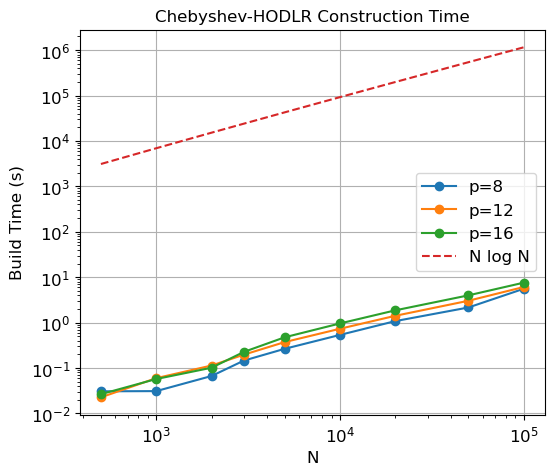

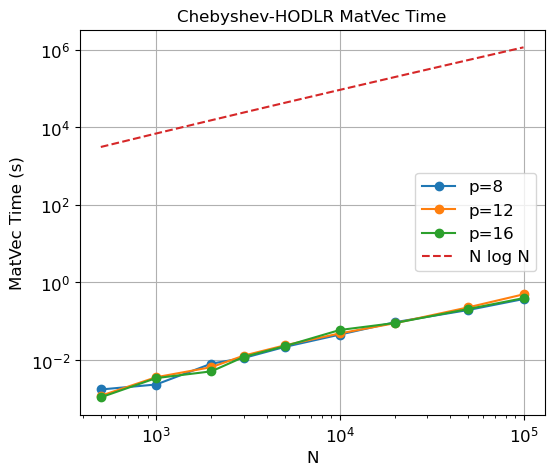

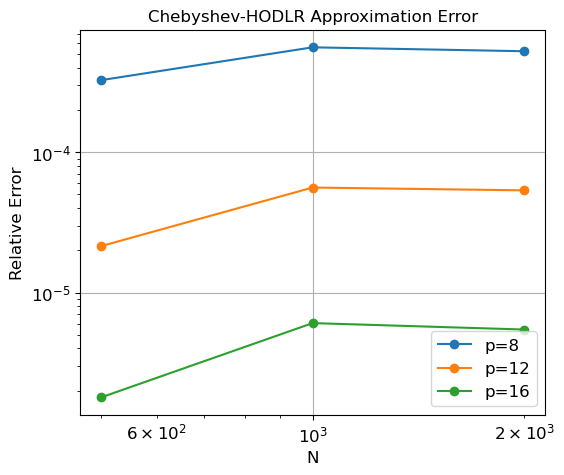

Generating Figure 3...


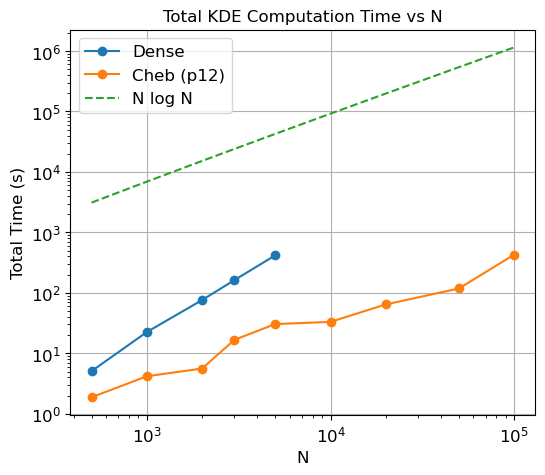

Generating Figure 4...


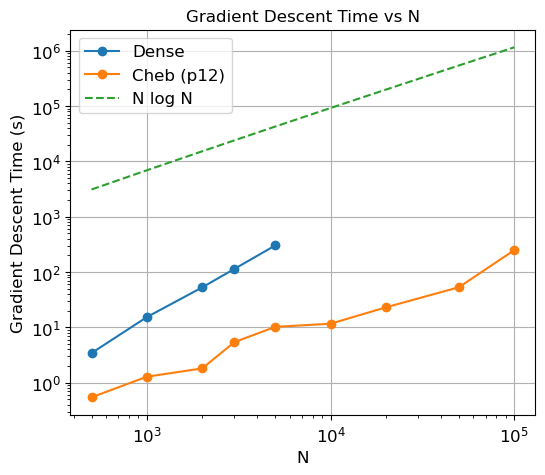

Generating Figure 5...


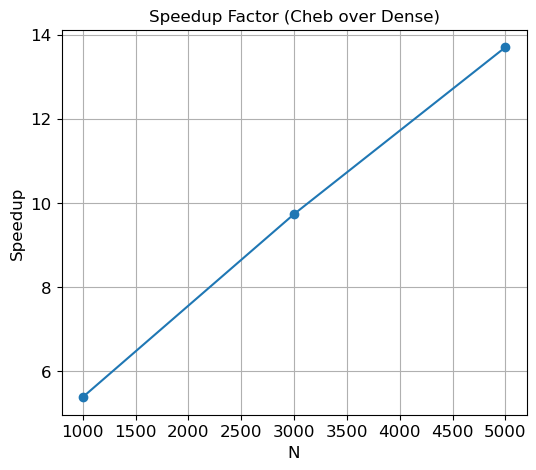

Generating Figure 6...


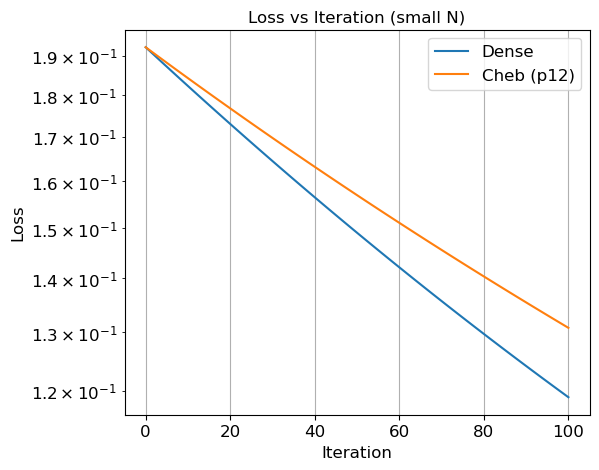

Generating Figure 7...


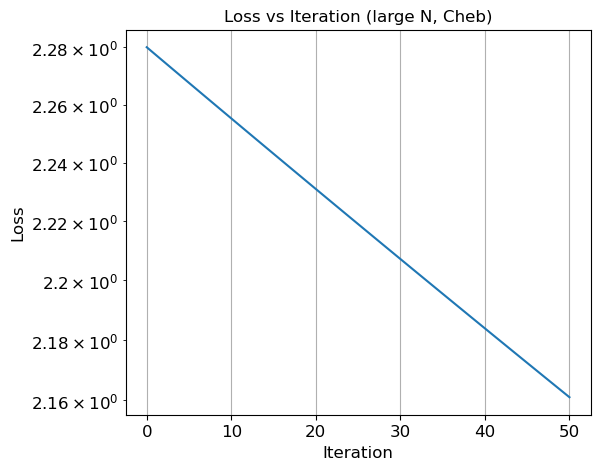

Generating Figure 8...


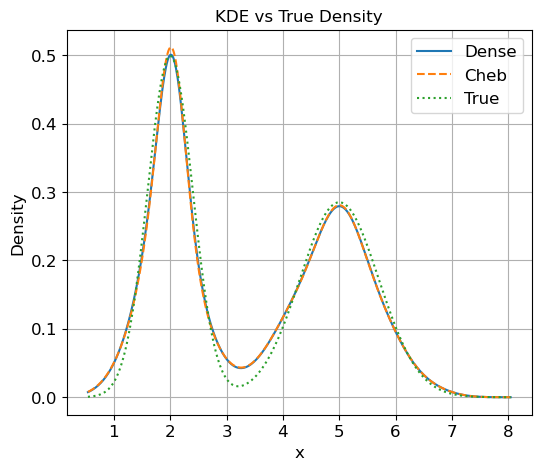

Generating Figure 9...


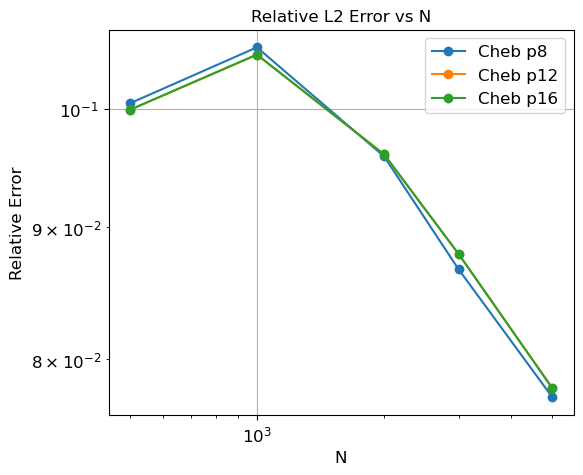


SUMMARY STATISTICS

Cheb p8:
  Avg speedup: 9.15x
  Max speedup: 14.20x
  Avg error: 9.32e-02

Cheb p12:
  Avg speedup: 9.02x
  Max speedup: 13.70x
  Avg error: 9.33e-02

Cheb p16:
  Avg speedup: 8.60x
  Max speedup: 12.53x
  Avg error: 9.33e-02


In [35]:
results, N_values = run_complete_analysis()

In [36]:
import pickle

with open("cheb_results.pkl", "wb") as f:
    pickle.dump((results, N_values), f)